# 한우 등급 예측 — 탐색적 데이터 분석 (EDA)

기상청 빅데이터 콘테스트 주제2: 기상에 따른 한우 등급 예측

**데이터셋:**
| 파일 | 설명 | 행 수 |
|------|------|------:|
| `hanwoo_train.csv` | 도축·등급판정 훈련 데이터 | 2,408,699 |
| `hanwoo_weather.csv` | 기상 관측 데이터 | 973,248 |
| `hanwoo_area.csv` | 농장별 사육두수·면적 | 91,896 |
| `hanwoo_death.csv` | 폐사 기록 | 321,389 |
| `hanwoo_lineage.csv` | 혈통 정보 | 1,809,455 |

**예측 대상:** `LAST_GRADE` (최종 등급 = 육질등급 + 육량등급)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc

rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


---
## 1. 데이터 로드

In [2]:
train = pd.read_csv('data/hanwoo_train.csv', encoding='utf-8-sig')
weather = pd.read_csv('data/hanwoo_weather.csv', encoding='utf-8-sig')
area = pd.read_csv('data/hanwoo_area.csv', encoding='utf-8-sig')
death = pd.read_csv('data/hanwoo_death.csv', encoding='utf-8-sig')
lineage = pd.read_csv('data/hanwoo_lineage.csv', encoding='utf-8-sig')

# -99를 결측값으로 치환
MISSING = -99
replace_cols = ['BACKFAT', 'REA', 'WINDEX', 'INSFAT', 'YUKSAK', 'FATSAK', 'TISSUE', 'GROWTH', 'COST_AMT']
for col in replace_cols:
    train[col] = train[col].replace(MISSING, np.nan)

train['WGRADE'] = train['WGRADE'].replace('-99.0', np.nan)
death['DEAD_REASON'] = death['DEAD_REASON'].replace('-99', np.nan)

print(f'훈련 데이터: {train.shape[0]:,}행 × {train.shape[1]}열')

훈련 데이터: 2,408,699행 × 23열


---
## 2. 데이터 기본 정보

In [3]:
datasets = {
    '훈련(train)': train,
    '기상(weather)': weather,
    '사육면적(area)': area,
    '폐사(death)': death,
    '혈통(lineage)': lineage
}

for name, df in datasets.items():
    print(f'\n{"="*60}')
    print(f'📋 {name}: {df.shape[0]:,}행 × {df.shape[1]}열')
    print(f'칼럼: {list(df.columns)}')
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f'\n결측값:')
        for col, cnt in missing.items():
            print(f'  {col}: {cnt:,} ({cnt/len(df)*100:.1f}%)')
    else:
        print('결측값 없음')


📋 훈련(train): 2,408,699행 × 23열
칼럼: ['sido', 'sigungu', 'eupmyeondong', 'stn', 'ABATT_DATE', 'JUDGE_DATE', 'JUDGE_SEX', 'WEIGHT', 'BACKFAT', 'REA', 'WINDEX', 'WGRADE', 'INSFAT', 'YUKSAK', 'FATSAK', 'TISSUE', 'GROWTH', 'COST_AMT', 'AGE', 'BIRTH_YMD', 'CATTLE_NO', 'FARM_UNIQUE_NO', 'LAST_GRADE']

결측값:
  BACKFAT: 4,567 (0.2%)
  REA: 5,188 (0.2%)
  WINDEX: 5,252 (0.2%)
  WGRADE: 4,814 (0.2%)
  INSFAT: 5,331 (0.2%)
  YUKSAK: 5,269 (0.2%)
  FATSAK: 4,743 (0.2%)
  TISSUE: 5,320 (0.2%)
  GROWTH: 9 (0.0%)
  COST_AMT: 885,003 (36.7%)

📋 기상(weather): 973,248행 × 7열
칼럼: ['stn', 'date', 'ta_max', 'rn_day', 'ta_min', 'rhm_avg', 'ws_davg']
결측값 없음

📋 사육면적(area): 91,896행 × 5열
칼럼: ['FARM_UNIQUE_NO', 'C2023', 'C2024', 'C2025', 'AREA']
결측값 없음

📋 폐사(death): 321,389행 × 4열
칼럼: ['FARM_UNIQUE_NO', 'BIRTH_YMD', 'DEAD_YMD', 'DEAD_REASON']

결측값:
  DEAD_REASON: 234,276 (72.9%)

📋 혈통(lineage): 1,809,455행 × 8열
칼럼: ['CATTLE_NO', 'KPN_NO', 'FATHER_CATTLE_NO', 'MOTHER_ANIMAL_NO', 'F_GMOTHER_ANIMAL_NO', 'F_GFATHER_CATTLE_

---
## 3. 훈련 데이터 기초 통계

In [4]:
train.describe().round(2)

,stn,WEIGHT,BACKFAT,REA,WINDEX,INSFAT,YUKSAK,FATSAK,TISSUE,GROWTH,COST_AMT,AGE,BIRTH_YMD
count,2408699.00,2408699.00,2404132.00,2403511.00,2403447.00,2403368.00,2403430.00,2403956.00,2403379.00,2408690.00,1523696.00,2408699.00,2408699.00
mean,590.24,422.75,12.63,93.12,61.51,5.42,4.97,3.07,2.18,4.18,16661.81,42.57,20206114.74
std,252.00,79.84,5.45,15.06,1.82,2.20,0.49,0.37,1.06,2.15,4212.82,21.86,20525.88
min,93.00,3.00,1.00,1.00,29.19,1.00,1.00,1.00,1.00,1.00,0.00,1.00,19960101.00
25%,288.00,367.00,9.00,84.00,60.40,4.00,5.00,3.00,1.00,3.00,13900.00,31.00,20200520.00
50%,672.00,423.00,12.00,93.00,61.58,6.00,5.00,3.00,2.00,3.00,16949.00,33.00,20210516.00
75%,785.00,479.00,15.00,103.00,62.63,7.00,5.00,3.00,3.00,6.00,19400.00,47.00,20220501.00
max,964.00,881.00,98.00,196.00,77.32,9.00,8.00,8.00,5.00,9.00,150000.00,344.00,20250826.00


In [5]:
print('=== 성별 분포 ===')
print(train['JUDGE_SEX'].value_counts())
print(f'\n=== 시도별 건수 (상위 10) ===')
print(train['sido'].value_counts().head(10))

=== 성별 분포 ===
JUDGE_SEX
거세    1222465
암     1174414
수       11820
Name: count, dtype: int64

=== 시도별 건수 (상위 10) ===
sido
경상북도       605621
전라남도       409421
전북특별자치도    295666
충청남도       289493
경기도        214181
경상남도       203066
강원특별자치도    153026
충청북도       138979
울산광역시       20519
제주특별자치도     19448
Name: count, dtype: int64


---
## 4. 최종 등급 (LAST_GRADE) 분석

최종 등급 = 육질등급(1++, 1+, 1, 2, 3) + 육량등급(A, B, C)

In [6]:
# 육질등급·육량등급 분리
train['육질등급'] = train['LAST_GRADE'].str.extract(r'^(1\+\+|1\+|1|2|3|등외)')[0]
train['육량등급'] = train['LAST_GRADE'].str.extract(r'(A|B|C)$')[0]

grade_order = ['1++A','1++B','1++C','1+A','1+B','1+C','1A','1B','1C','2A','2B','2C','3A','3B','3C','등외']
quality_order = ['1++','1+','1','2','3','등외']
yield_order = ['A','B','C']

print('=== 최종 등급 분포 ===')
grade_counts = train['LAST_GRADE'].value_counts().reindex(grade_order).dropna()
print(grade_counts)

=== 최종 등급 분포 ===
LAST_GRADE
1++A    207026
1++B    319588
1++C    128997
1+A     167246
1+B     311222
1+C     130094
1A      168174
1B      299290
1C      116976
2A      127410
2B      195866
2C       62938
3A       47214
3B       97576
3C       23542
등외        5540
Name: count, dtype: int64


/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/2397420801.py:24: UserWarning: Glyph 46321 (\N{HANGUL SYLLABLE DEUNG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/2397420801.py:24: UserWarning: Glyph 50808 (\N{HANGUL SYLLABLE OE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/2397420801.py:24: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/2397420801.py:24: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/2397420801.py:24: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/2397420801.py:24: U

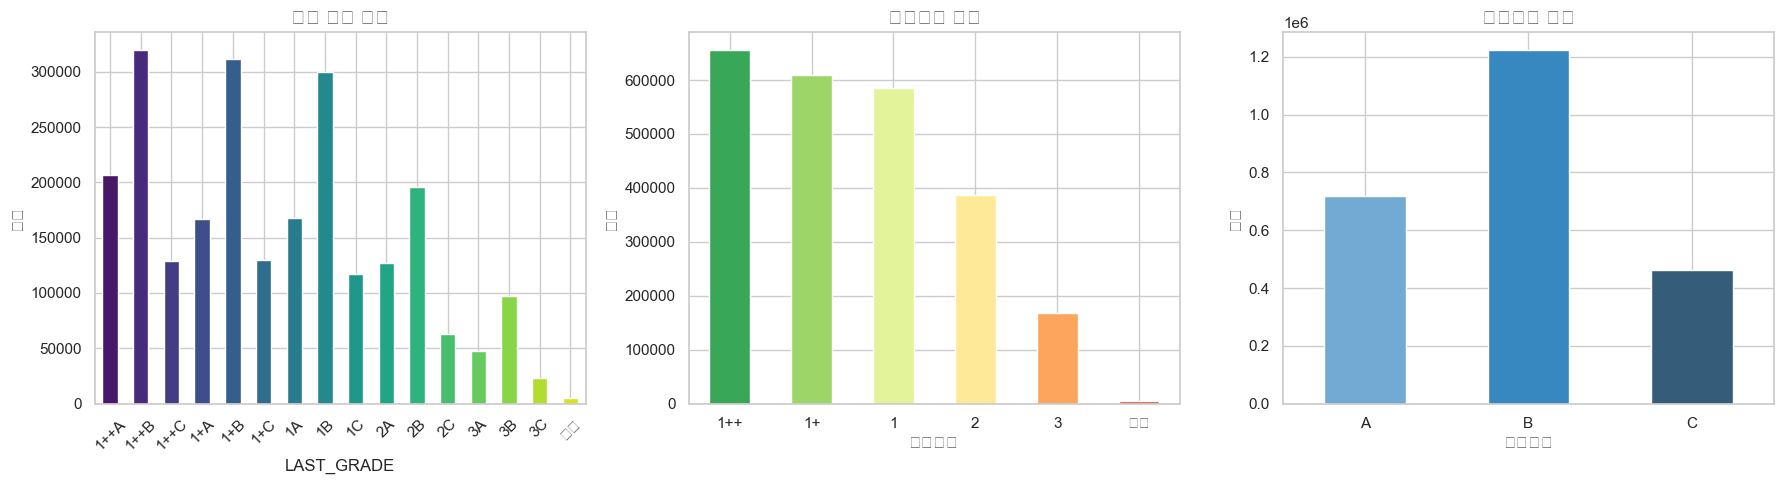

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 최종 등급 분포
colors = sns.color_palette('viridis', len(grade_counts))
grade_counts.plot.bar(ax=axes[0], color=colors)
axes[0].set_title('최종 등급 분포', fontsize=14)
axes[0].set_ylabel('건수')
axes[0].tick_params(axis='x', rotation=45)

# 육질등급 분포
q_counts = train['육질등급'].value_counts().reindex(quality_order).dropna()
q_counts.plot.bar(ax=axes[1], color=sns.color_palette('RdYlGn_r', len(q_counts)))
axes[1].set_title('육질등급 분포', fontsize=14)
axes[1].set_ylabel('건수')
axes[1].tick_params(axis='x', rotation=0)

# 육량등급 분포
y_counts = train['육량등급'].value_counts().reindex(yield_order).dropna()
y_counts.plot.bar(ax=axes[2], color=sns.color_palette('Blues_d', len(y_counts)))
axes[2].set_title('육량등급 분포', fontsize=14)
axes[2].set_ylabel('건수')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/2468047187.py:8: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/2468047187.py:8: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/2468047187.py:8: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/2468047187.py:8: UserWarning: Glyph 50516 (\N{HANGUL SYLLABLE AM}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/2468047187.py:8: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/2468047187.py:8: UserWarni

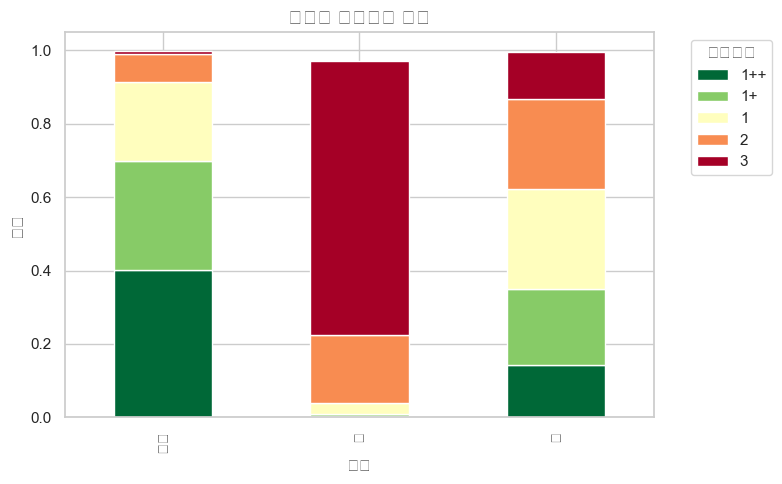

In [8]:
# 성별별 육질등급 비율
ct = pd.crosstab(train['JUDGE_SEX'], train['육질등급'], normalize='index')[quality_order[:-1]]
ct.plot.bar(stacked=True, figsize=(8, 5), colormap='RdYlGn_r')
plt.title('성별별 육질등급 비율', fontsize=14)
plt.ylabel('비율')
plt.xlabel('성별')
plt.legend(title='육질등급', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

---
## 5. 육량 관련 피처 분석

육량등급 결정 요소: **도체중량(WEIGHT)**, **등지방두께(BACKFAT)**, **배최장근단면적(REA)** → **육량지수(WINDEX)**

/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/2864092215.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='육량등급', y=col, order=yield_order, ax=ax,
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/2864092215.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='육량등급', y=col, order=yield_order, ax=ax,
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/2864092215.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='육량등급', y=col, order=yield_order, ax=ax

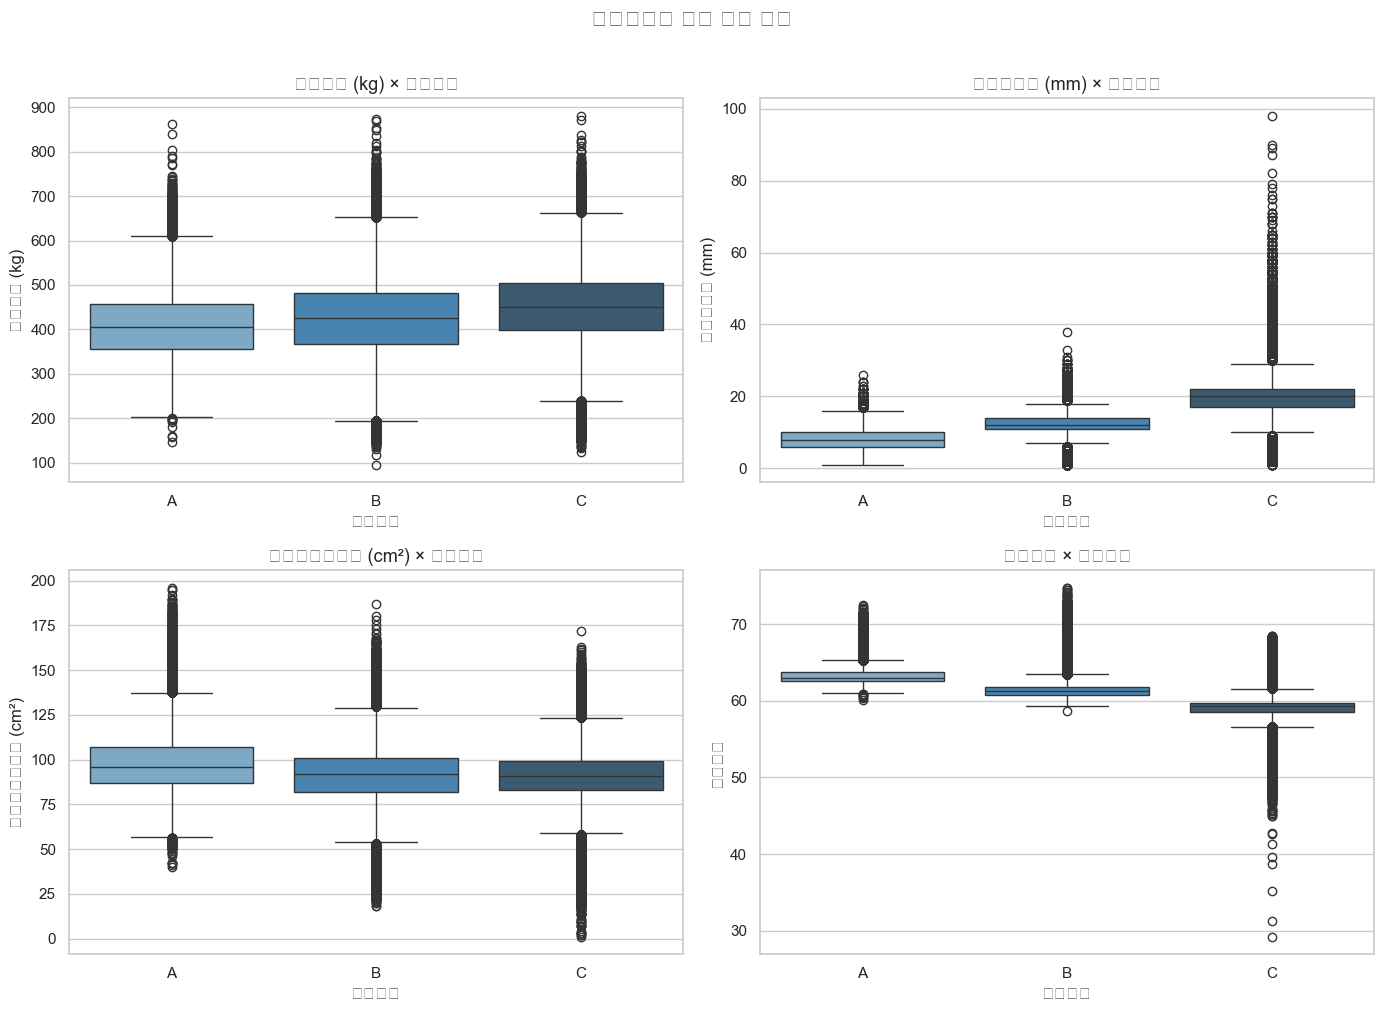

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col, label in zip(
    axes.flat,
    ['WEIGHT', 'BACKFAT', 'REA', 'WINDEX'],
    ['도체중량 (kg)', '등지방두께 (mm)', '배최장근단면적 (cm²)', '육량지수']
):
    sns.boxplot(data=train, x='육량등급', y=col, order=yield_order, ax=ax,
                palette='Blues_d')
    ax.set_title(f'{label} × 육량등급', fontsize=13)
    ax.set_xlabel('육량등급')
    ax.set_ylabel(label)

plt.suptitle('육량등급별 주요 피처 분포', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

---
## 6. 육질 관련 피처 분석

육질등급 결정 요소: **근내지방도(INSFAT)**, **육색(YUKSAK)**, **지방색(FATSAK)**, **조직감(TISSUE)**, **성숙도(GROWTH)**

/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/960382140.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='육질등급', y=col, order=quality_order[:-1],
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/960382140.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='육질등급', y=col, order=quality_order[:-1],
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/960382140.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='육질등급', y=col, order=quality_order[:-1]

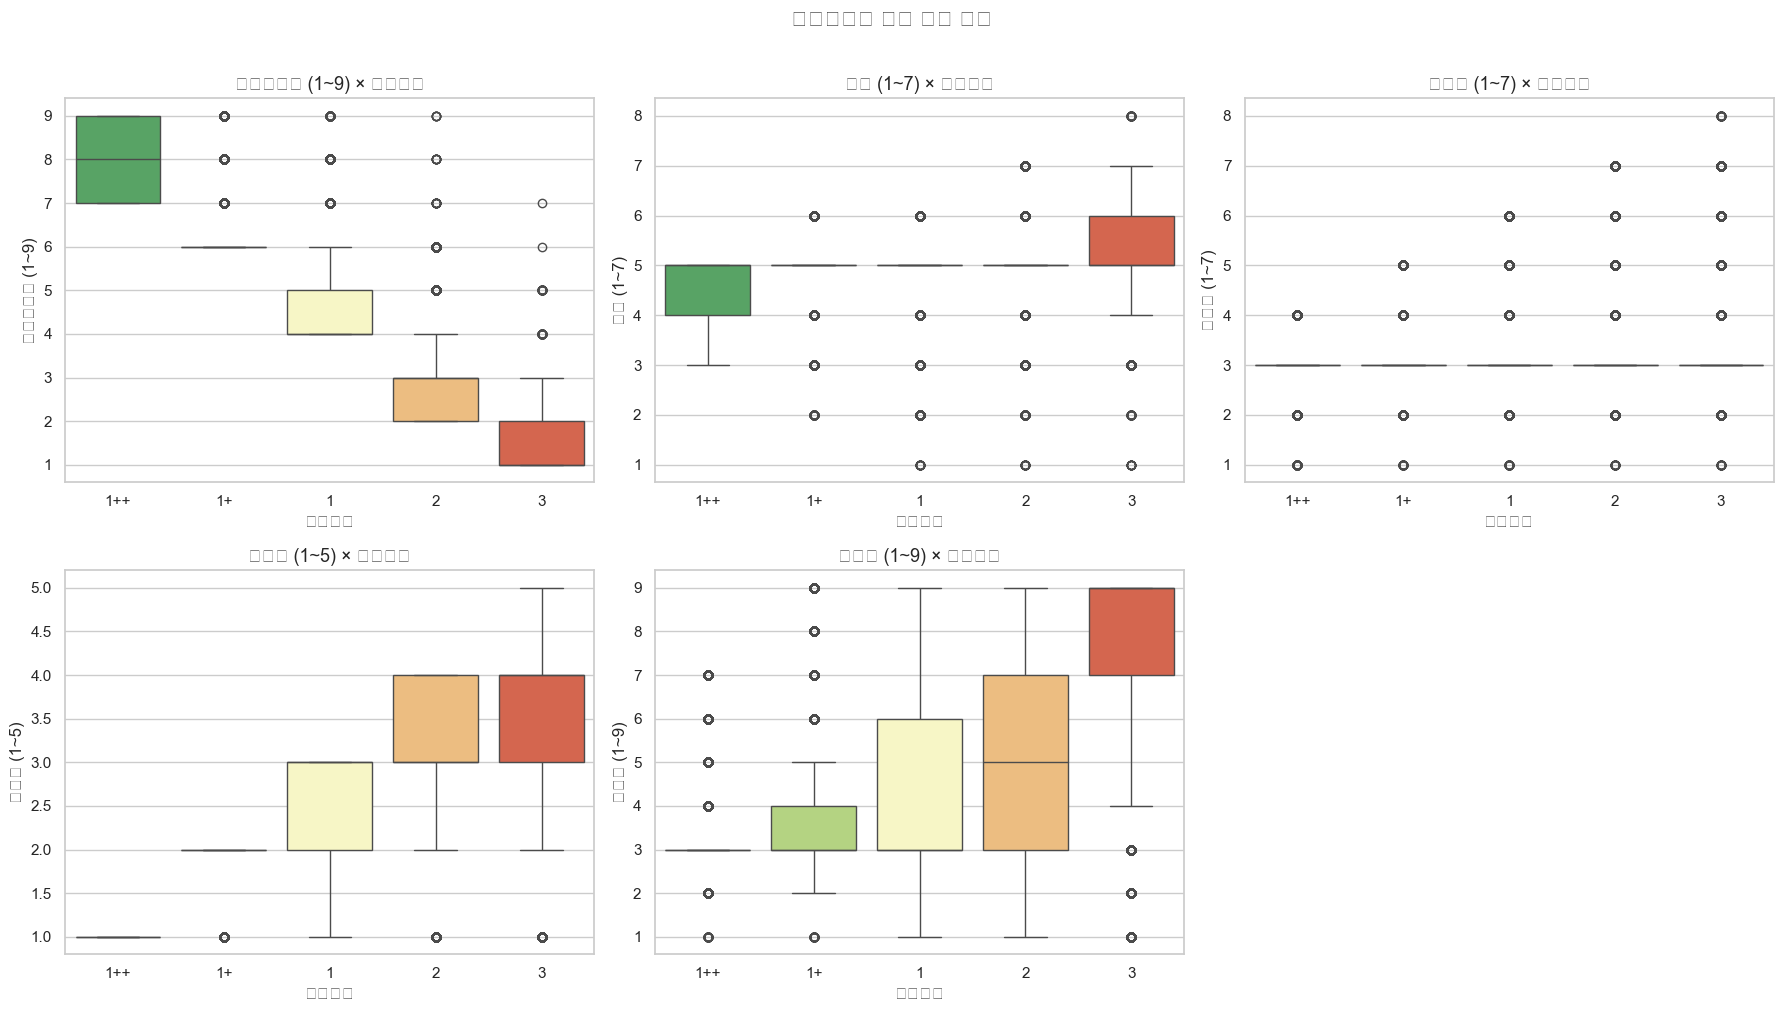

In [10]:
quality_cols = {
    'INSFAT': '근내지방도 (1~9)',
    'YUKSAK': '육색 (1~7)',
    'FATSAK': '지방색 (1~7)',
    'TISSUE': '조직감 (1~5)',
    'GROWTH': '성숙도 (1~9)'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flat

for (col, label), ax in zip(quality_cols.items(), axes_flat):
    sns.boxplot(data=train, x='육질등급', y=col, order=quality_order[:-1],
                ax=ax, palette='RdYlGn_r')
    ax.set_title(f'{label} × 육질등급', fontsize=13)
    ax.set_xlabel('육질등급')
    ax.set_ylabel(label)

axes_flat[-1].axis('off')  # 빈 칸 숨기기
plt.suptitle('육질등급별 주요 피처 분포', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

---
## 7. 월령(AGE) & 도체중량(WEIGHT) 분석

/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/527392825.py:22: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/527392825.py:22: UserWarning: Glyph 47161 (\N{HANGUL SYLLABLE RYEONG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/527392825.py:22: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/527392825.py:22: UserWarning: Glyph 48128 (\N{HANGUL SYLLABLE MIL}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/527392825.py:22: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/527392825.py:22: UserW

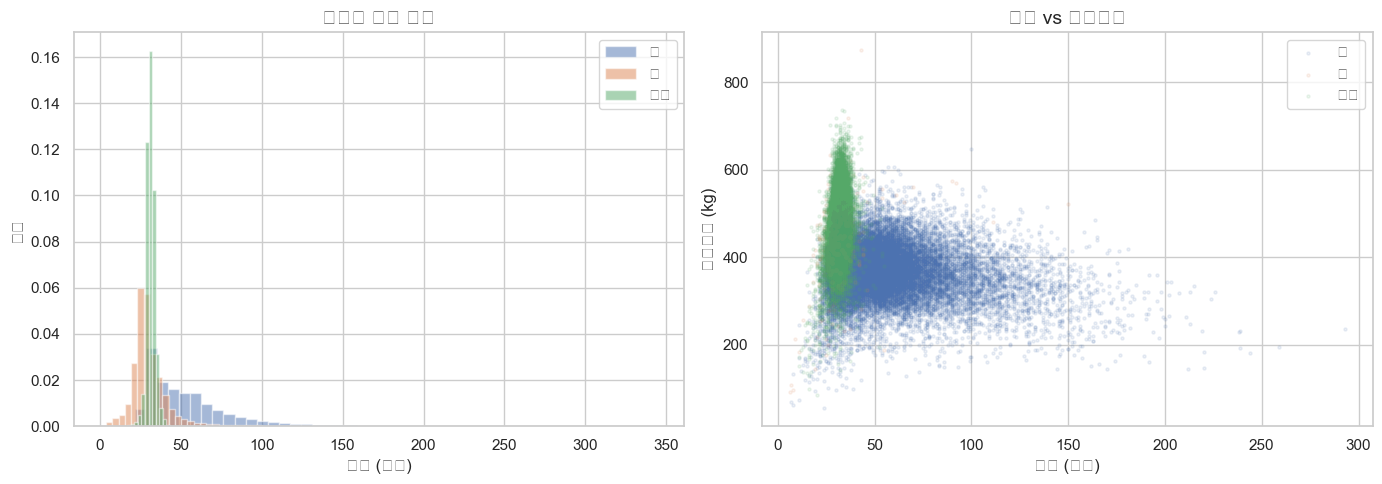

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 성별별 월령 분포
for sex in ['암', '수', '거세']:
    subset = train[train['JUDGE_SEX'] == sex]['AGE']
    axes[0].hist(subset, bins=50, alpha=0.5, label=sex, density=True)
axes[0].set_title('성별별 월령 분포', fontsize=14)
axes[0].set_xlabel('월령 (개월)')
axes[0].set_ylabel('밀도')
axes[0].legend()

# 월령 vs 도체중량 (성별)
sample = train.sample(min(50000, len(train)), random_state=42)
for sex in ['암', '수', '거세']:
    s = sample[sample['JUDGE_SEX'] == sex]
    axes[1].scatter(s['AGE'], s['WEIGHT'], alpha=0.1, s=5, label=sex)
axes[1].set_title('월령 vs 도체중량', fontsize=14)
axes[1].set_xlabel('월령 (개월)')
axes[1].set_ylabel('도체중량 (kg)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 8. 수치형 피처 상관관계

/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/934306554.py:9: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/934306554.py:9: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/934306554.py:9: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/934306554.py:9: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/934306554.py:9: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/934306554.py:9: UserWarning: G

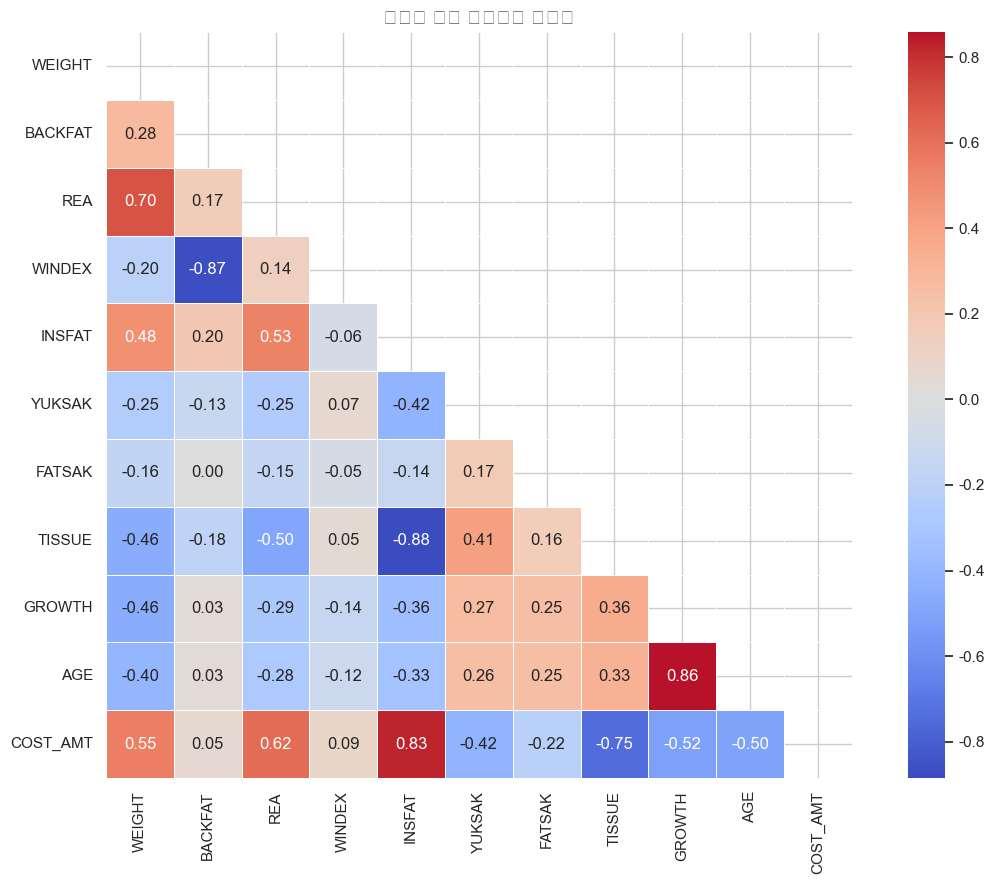

In [12]:
numeric_cols = ['WEIGHT', 'BACKFAT', 'REA', 'WINDEX', 'INSFAT', 'YUKSAK', 'FATSAK', 'TISSUE', 'GROWTH', 'AGE', 'COST_AMT']
corr = train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('수치형 피처 상관관계 히트맵', fontsize=14)
plt.tight_layout()
plt.show()

---
## 9. 시도별 등급 분석

/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/3828970979.py:13: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/3828970979.py:13: UserWarning: Glyph 52380 (\N{HANGUL SYLLABLE CEON}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/3828970979.py:13: UserWarning: Glyph 44305 (\N{HANGUL SYLLABLE GWANG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/3828970979.py:13: UserWarning: Glyph 50669 (\N{HANGUL SYLLABLE YEOG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/3828970979.py:13: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/3828970979.py:13: 

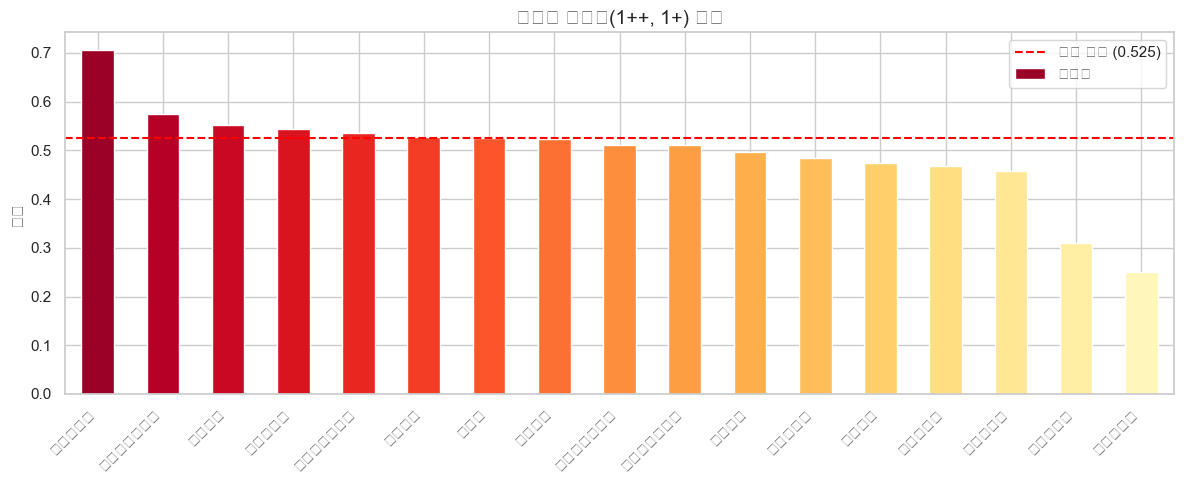

In [13]:
# 시도별 1++/1+ 비율
train['고등급'] = train['육질등급'].isin(['1++', '1+'])
sido_rate = train.groupby('sido')['고등급'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
sido_rate.plot.bar(ax=ax, color=sns.color_palette('YlOrRd_r', len(sido_rate)))
ax.set_title('시도별 고등급(1++, 1+) 비율', fontsize=14)
ax.set_ylabel('비율')
ax.set_xlabel('')
ax.axhline(y=train['고등급'].mean(), color='red', linestyle='--', label=f'전체 평균 ({train["고등급"].mean():.3f})')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

train.drop(columns='고등급', inplace=True)

---
## 10. 도축 시기별 추이

/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/377250052.py:25: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/377250052.py:25: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/377250052.py:25: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/377250052.py:25: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/377250052.py:25: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/377250052.py:25: UserWa

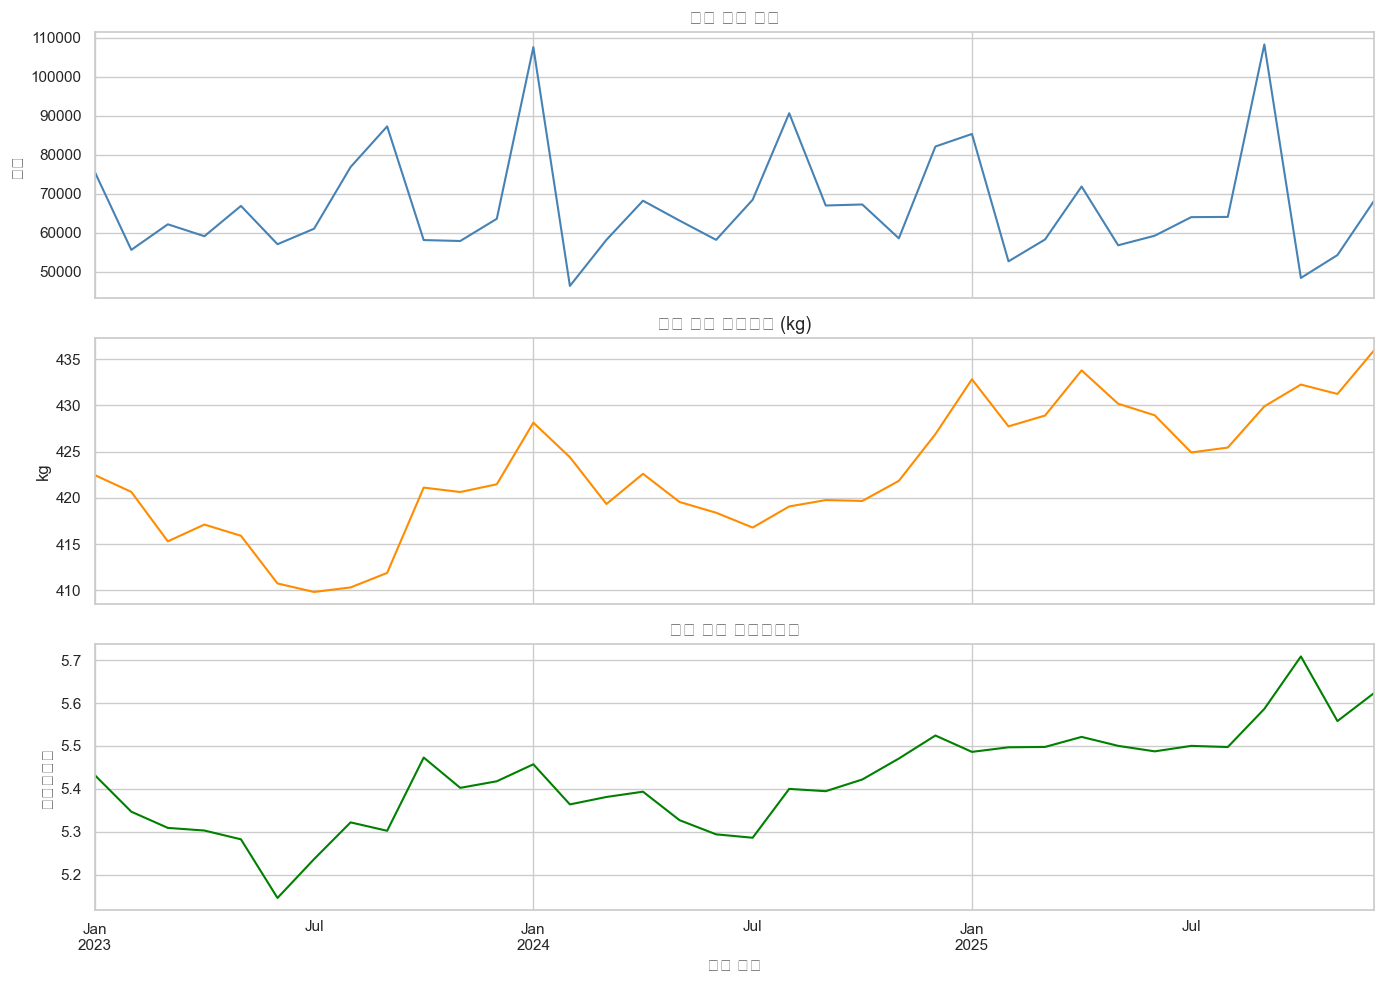

In [14]:
train['ABATT_DATE'] = pd.to_datetime(train['ABATT_DATE'])
train['도축연월'] = train['ABATT_DATE'].dt.to_period('M')

monthly = train.groupby('도축연월').agg(
    건수=('LAST_GRADE', 'size'),
    평균중량=('WEIGHT', 'mean'),
    평균근내지방도=('INSFAT', 'mean')
)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

monthly['건수'].plot(ax=axes[0], color='steelblue')
axes[0].set_title('월별 도축 건수', fontsize=13)
axes[0].set_ylabel('건수')

monthly['평균중량'].plot(ax=axes[1], color='darkorange')
axes[1].set_title('월별 평균 도체중량 (kg)', fontsize=13)
axes[1].set_ylabel('kg')

monthly['평균근내지방도'].plot(ax=axes[2], color='green')
axes[2].set_title('월별 평균 근내지방도', fontsize=13)
axes[2].set_ylabel('근내지방도')

plt.xlabel('도축 연월')
plt.tight_layout()
plt.show()

---
## 11. 기상 데이터 탐색

In [15]:
weather['date'] = pd.to_datetime(weather['date'])
print(f'기간: {weather["date"].min()} ~ {weather["date"].max()}')
print(f'관측소 수: {weather["stn"].nunique()}')
print(f'\n기상 데이터 기초 통계:')
weather.describe().round(2)

기간: 2020-01-01 00:00:00 ~ 2025-12-31 00:00:00
관측소 수: 444

기상 데이터 기초 통계:


,stn,date,ta_max,rn_day,ta_min,rhm_avg,ws_davg
count,973248.00,973248,973248.00,973248.00,973248.00,973248.00,973248.00
mean,590.55,2022-12-31 12:00:00,17.51,2.13,6.98,63.77,0.41
min,90.00,2020-01-01 00:00:00,-99.00,-99.00,-99.00,-99.00,-99.00
25%,426.00,2021-07-01 18:00:00,10.70,0.00,-0.60,60.00,1.00
50%,629.50,2022-12-31 12:00:00,20.00,0.00,8.10,73.40,1.50
75%,785.25,2024-07-01 06:00:00,27.00,0.50,17.80,83.00,2.20
max,964.00,2025-12-31 00:00:00,43.40,438.90,33.30,100.00,22.30
std,243.34,NaN,16.40,19.06,15.99,39.95,11.89


/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/2029614936.py:19: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/2029614936.py:19: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/2029614936.py:19: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/2029614936.py:19: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/2029614936.py:19: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/zqppdfl15vs4jmj1_fsw_mt40000gn/T/ipykernel_46648/2029614936.py:19: UserWa

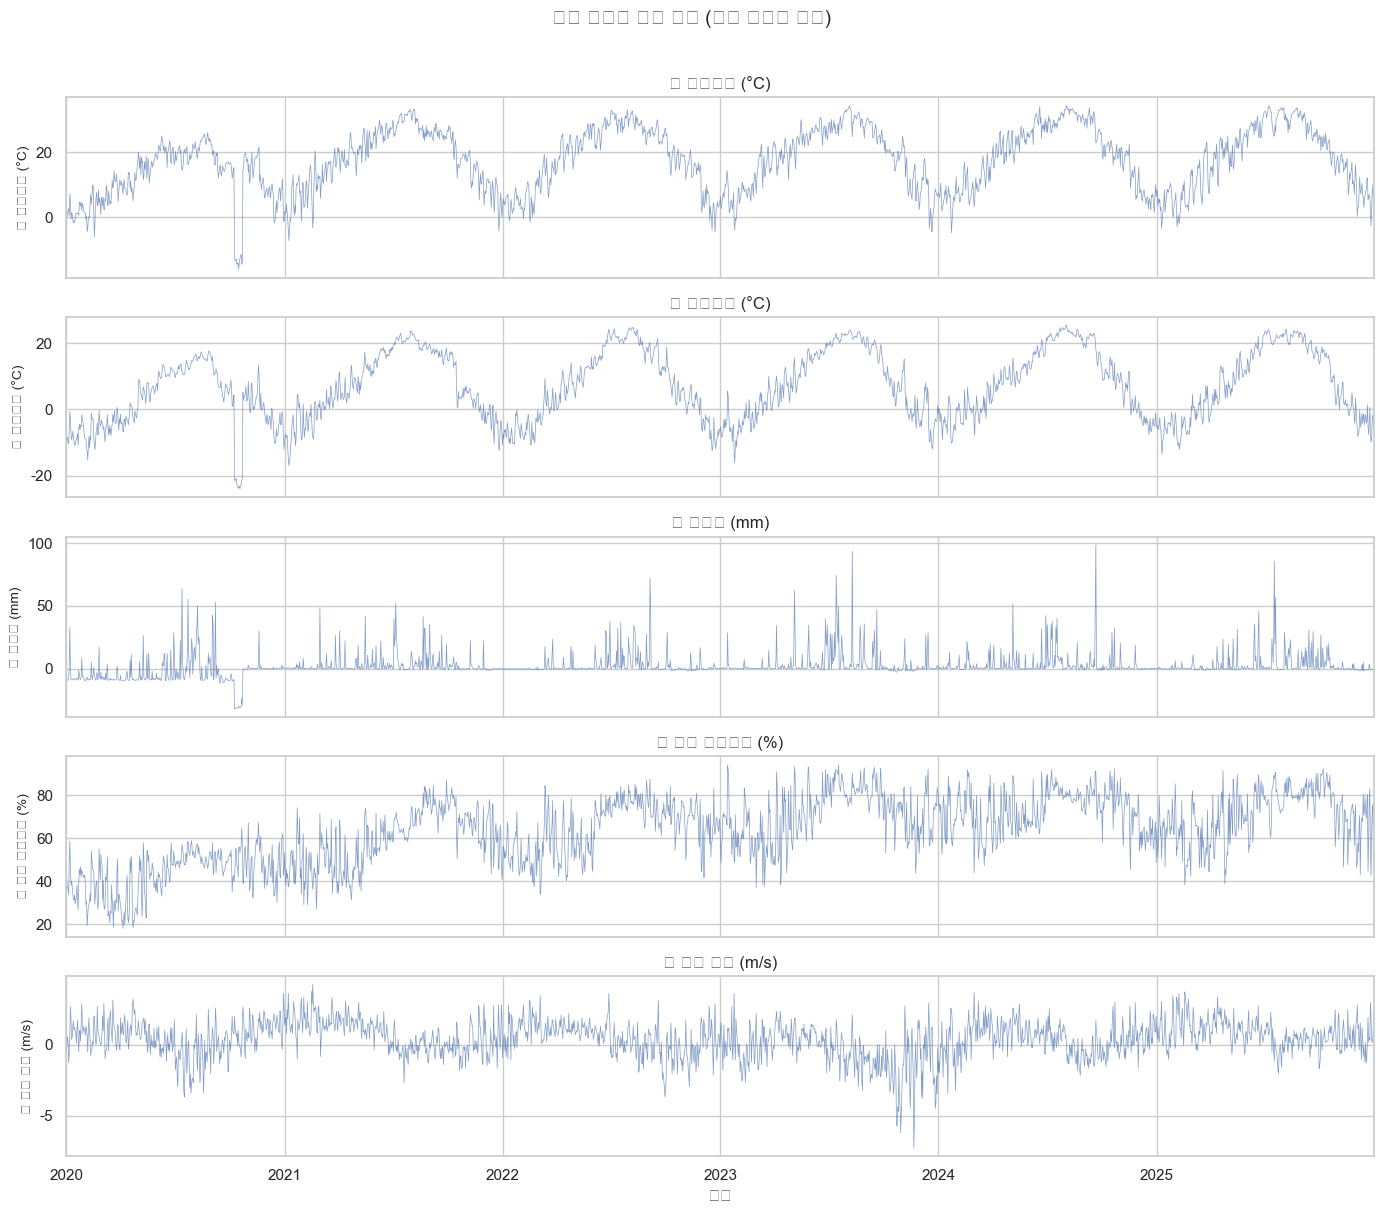

In [16]:
weather_cols = {
    'ta_max': '일 최고기온 (°C)',
    'ta_min': '일 최저기온 (°C)',
    'rn_day': '일 강수량 (mm)',
    'rhm_avg': '일 평균 상대습도 (%)',
    'ws_davg': '일 평균 풍속 (m/s)'
}

fig, axes = plt.subplots(len(weather_cols), 1, figsize=(14, 12), sharex=True)
daily_avg = weather.groupby('date')[list(weather_cols.keys())].mean()

for ax, (col, label) in zip(axes, weather_cols.items()):
    daily_avg[col].plot(ax=ax, linewidth=0.5, alpha=0.7)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(label, fontsize=12)

plt.xlabel('날짜')
plt.suptitle('기상 데이터 일별 추이 (전체 관측소 평균)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 12. 사육면적 데이터 탐색

농장 수: 86,703

연도별 평균 사육두수:
  C2023: 31.8마리
  C2024: 23.9마리
  C2025: 17.6마리

평균 축사 면적: 492.3 m²


ValueError: supplied range of [-inf, 297.0] is not finite

/opt/homebrew/Caskroom/miniforge/base/envs/hanwoo/lib/python3.11/site-packages/IPython/core/events.py:100: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) Arial.
  func(*args, **kwargs)
/opt/homebrew/Caskroom/miniforge/base/envs/hanwoo/lib/python3.11/site-packages/IPython/core/events.py:100: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) Arial.
  func(*args, **kwargs)
/opt/homebrew/Caskroom/miniforge/base/envs/hanwoo/lib/python3.11/site-packages/IPython/core/events.py:100: UserWarning: Glyph 52629 (\N{HANGUL SYLLABLE CUG}) missing from font(s) Arial.
  func(*args, **kwargs)
/opt/homebrew/Caskroom/miniforge/base/envs/hanwoo/lib/python3.11/site-packages/IPython/core/events.py:100: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) Arial.
  func(*args, **kwargs)
/opt/homebrew/Caskroom/miniforge/base/envs/hanwoo/lib/python3.11/site-packages/IPython/core/events.py:100: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) 

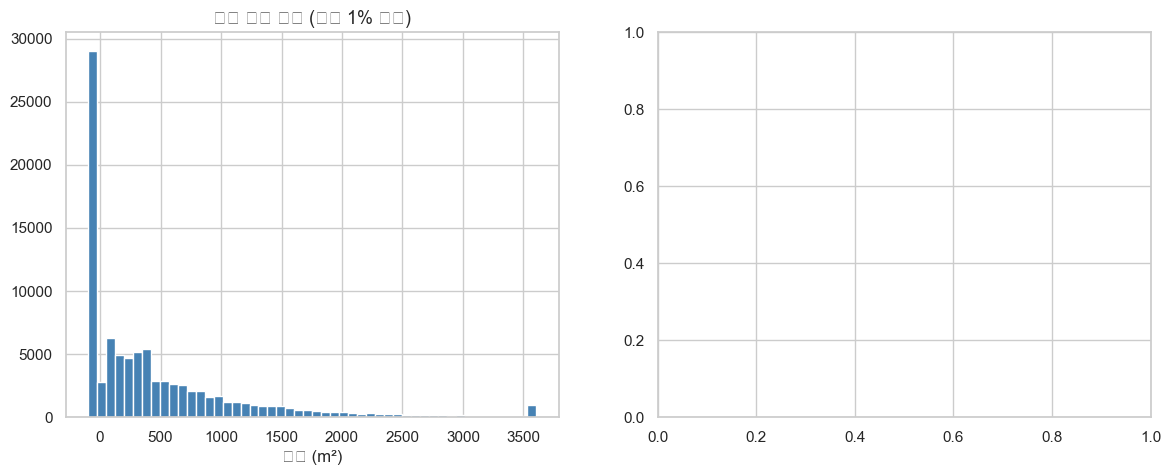

In [17]:
print(f'농장 수: {area["FARM_UNIQUE_NO"].nunique():,}')
print(f'\n연도별 평균 사육두수:')
for col in ['C2023', 'C2024', 'C2025']:
    print(f'  {col}: {area[col].mean():.1f}마리')
print(f'\n평균 축사 면적: {area["AREA"].mean():.1f} m²')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 두당 면적 산출
area['두당면적'] = area['AREA'] / area[['C2023','C2024','C2025']].mean(axis=1)

area['AREA'].clip(upper=area['AREA'].quantile(0.99)).hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('축사 면적 분포 (상위 1% 제외)', fontsize=13)
axes[0].set_xlabel('면적 (m²)')

area['두당면적'].clip(upper=area['두당면적'].quantile(0.99)).hist(bins=50, ax=axes[1], color='darkorange')
axes[1].set_title('두당 면적 분포 (상위 1% 제외)', fontsize=13)
axes[1].set_xlabel('두당 면적 (m²/마리)')

plt.tight_layout()
plt.show()

---
## 13. 폐사 데이터 탐색

In [ ]:
death['BIRTH_YMD'] = pd.to_datetime(death['BIRTH_YMD'].astype(str), format='%Y%m%d', errors='coerce')
death['DEAD_YMD'] = pd.to_datetime(death['DEAD_YMD'].astype(str), format='%Y%m%d', errors='coerce')
death['수명_일'] = (death['DEAD_YMD'] - death['BIRTH_YMD']).dt.days
death['수명_월'] = death['수명_일'] / 30.44

print(f'폐사 건수: {len(death):,}')
print(f'평균 수명: {death["수명_월"].mean():.1f}개월')
print(f'폐사일 범위: {death["DEAD_YMD"].min()} ~ {death["DEAD_YMD"].max()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

death['수명_월'].clip(upper=120).hist(bins=60, ax=axes[0], color='indianred')
axes[0].set_title('폐사 개체 수명 분포', fontsize=13)
axes[0].set_xlabel('수명 (개월)')
axes[0].axvline(death['수명_월'].median(), color='black', linestyle='--', label=f'중앙값: {death["수명_월"].median():.0f}개월')
axes[0].legend()

death.set_index('DEAD_YMD').resample('M').size().plot(ax=axes[1], color='indianred')
axes[1].set_title('월별 폐사 건수 추이', fontsize=13)
axes[1].set_ylabel('건수')
axes[1].set_xlabel('날짜')

plt.tight_layout()
plt.show()

---
## 14. 혈통 데이터 탐색

In [ ]:
print(f'전체 개체 수: {lineage["CATTLE_NO"].nunique():,}')
print(f'고유 부(아비) 수: {lineage["FATHER_CATTLE_NO"].nunique():,}')
print(f'고유 KPN 번호 수: {lineage["KPN_NO"].nunique():,}')

# 아비별 자손 수 분포
father_counts = lineage['FATHER_CATTLE_NO'].value_counts()
print(f'\n아비별 자손 수 통계:')
print(father_counts.describe().round(1))

fig, ax = plt.subplots(figsize=(10, 5))
father_counts.clip(upper=father_counts.quantile(0.95)).hist(bins=50, ax=ax, color='mediumpurple')
ax.set_title('아비별 자손 수 분포 (상위 5% 제외)', fontsize=13)
ax.set_xlabel('자손 수')
ax.set_ylabel('아비 수')
plt.tight_layout()
plt.show()

---
## 15. 경락가격 분석

In [ ]:
cost_valid = train[train['COST_AMT'].notna()].copy()
print(f'경락가격 유효 건수: {len(cost_valid):,} ({len(cost_valid)/len(train)*100:.1f}%)')
print(f'평균 경락가격: {cost_valid["COST_AMT"].mean():,.0f}원')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 육질등급별 경락가격
sns.boxplot(data=cost_valid, x='육질등급', y='COST_AMT', order=quality_order[:-1],
            ax=axes[0], palette='RdYlGn_r')
axes[0].set_title('육질등급별 경락가격', fontsize=13)
axes[0].set_ylabel('경락가격 (원)')
axes[0].set_xlabel('육질등급')

# 근내지방도 vs 경락가격
sns.boxplot(data=cost_valid, x='INSFAT', y='COST_AMT', ax=axes[1], palette='YlOrRd')
axes[1].set_title('근내지방도별 경락가격', fontsize=13)
axes[1].set_ylabel('경락가격 (원)')
axes[1].set_xlabel('근내지방도')

plt.tight_layout()
plt.show()

---
## 16. 데이터 조인 가능성 확인

```
hanwoo_train (메인)
  ├── stn ──────────── hanwoo_weather.stn
  ├── FARM_UNIQUE_NO ─ hanwoo_area.FARM_UNIQUE_NO
  ├── FARM_UNIQUE_NO ─ hanwoo_death.FARM_UNIQUE_NO
  └── CATTLE_NO ────── hanwoo_lineage.CATTLE_NO
```

In [ ]:
# 조인 키 매칭률 확인
train_stn = set(train['stn'].unique())
weather_stn = set(weather['stn'].unique())
print(f'[stn] train: {len(train_stn)}개, weather: {len(weather_stn)}개, 교집합: {len(train_stn & weather_stn)}개')

train_farm = set(train['FARM_UNIQUE_NO'].unique())
area_farm = set(area['FARM_UNIQUE_NO'].unique())
death_farm = set(death['FARM_UNIQUE_NO'].unique())
print(f'[FARM_UNIQUE_NO] train: {len(train_farm):,}개')
print(f'  → area 매칭: {len(train_farm & area_farm):,}개 ({len(train_farm & area_farm)/len(train_farm)*100:.1f}%)')
print(f'  → death 매칭: {len(train_farm & death_farm):,}개 ({len(train_farm & death_farm)/len(train_farm)*100:.1f}%)')

train_cattle = set(train['CATTLE_NO'].unique())
lineage_cattle = set(lineage['CATTLE_NO'].unique())
print(f'[CATTLE_NO] train: {len(train_cattle):,}개, lineage: {len(lineage_cattle):,}개, 매칭: {len(train_cattle & lineage_cattle):,}개 ({len(train_cattle & lineage_cattle)/len(train_cattle)*100:.1f}%)')

---
## 요약

### 주요 발견사항
- **최종 등급**은 육질등급(1++~3) + 육량등급(A~C) 조합으로 총 16개 클래스
- **근내지방도(INSFAT)**가 육질등급과 가장 강한 연관성
- **성별(JUDGE_SEX)**에 따라 등급 분포가 크게 다름 (거세가 고등급 비율 높을 것으로 예상)
- **경락가격**은 등급과 강한 양의 상관관계

### 다음 단계
1. 기상 데이터 병합: `stn` + 도축일 기준 사육 기간 중 기상 피처 집계
2. 사육면적 데이터 병합: 두당 면적, 사육 규모 등 파생변수 생성
3. 혈통 데이터 병합: 아비·KPN별 등급 통계 파생변수
4. 결측값 처리 전략 수립
5. 등급 예측 모델 구축